# Fase 1 — Reconocimiento de Patrones: Firmas en Cheques Off-Line

**Descripción general**

La verificación de firmas consiste en determinar si, dada una colección de muestras de la firma de una persona, una firma adicional fue realizada por esa misma persona. La técnica *off-line* trabaja sobre imágenes digitalizadas del cheque en papel, por lo que la información dinámica del trazo se pierde y el sistema debe apoyarse exclusivamente en características morfológicas y estadísticas extraídas de la imagen.

El flujo de trabajo sigue cuatro etapas:
1. **Selección de datos** — carga del conjunto de imágenes de cheques y firmas.
2. **Pre-procesamiento** — segmentación y limpieza de la región de la firma.
3. **Extracción de características** — morfología matemática (erosión con elementos estructurantes).
4. **Aprendizaje supervisado** — entrenamiento y evaluación de cuatro clasificadores (BPNN, SVM, KNN, Naive Bayes).

---

## 0 · Dependencias

In [2]:
# ── Instalación (ejecutar sólo la primera vez) ────────────────────────────────
# !pip install numpy matplotlib scikit-image scikit-learn Pillow tqdm ipywidgets

import os
import re
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.notebook import tqdm

from skimage import color, filters, morphology, exposure
from skimage.morphology import binary_erosion

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print('✔  Dependencias cargadas correctamente.')

✔  Dependencias cargadas correctamente.


---
## Etapa 1 · Selección de Datos
### Adquisición de imágenes con firmas off-line en cheques

El primer paso es la adquisición de imágenes de cheques con firmas. El conjunto de datos utilizado tiene la siguiente estructura en disco:

```
dataset/
├── TrainSet/
│   ├── X/   ← imágenes del cheque completo  (X_<n>.png / .jpg)
│   └── y/   ← imagen de la firma aislada en negativo (y_<n>.png / .jpg)
└── TestSet/
    ├── X/
    └── y/
```

En `X` se almacenan los cheques originales y en `y` la firma extraída, en negativo (fondo negro, trazo blanco).

In [3]:
# ── Configuración de rutas ────────────────────────────────────────────────────
DATASET_ROOT = './'          # ← ajusta esta ruta a tu directorio

PATHS = {
    'train_X': os.path.join(DATASET_ROOT, 'TrainSet', 'X'),
    'train_y': os.path.join(DATASET_ROOT, 'TrainSet', 'y'),
    'test_X' : os.path.join(DATASET_ROOT, 'TestSet',  'X'),
    'test_y' : os.path.join(DATASET_ROOT, 'TestSet',  'y'),
}

# Extensiones soportadas
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')


def sorted_images(folder: str) -> list:
    """Devuelve los archivos de imagen ordenados numéricamente por su sufijo."""
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    files.sort(key=lambda f: int(re.search(r'(\d+)', f).group()))
    return [os.path.join(folder, f) for f in files]


train_X_paths = sorted_images(PATHS['train_X'])
train_y_paths = sorted_images(PATHS['train_y'])
test_X_paths  = sorted_images(PATHS['test_X'])
test_y_paths  = sorted_images(PATHS['test_y'])

print(f'Imágenes de entrenamiento (cheques) : {len(train_X_paths)}')
print(f'Imágenes de entrenamiento (firmas)  : {len(train_y_paths)}')
print(f'Imágenes de prueba       (cheques)  : {len(test_X_paths)}')
print(f'Imágenes de prueba       (firmas)   : {len(test_y_paths)}')
assert len(train_X_paths) == len(train_y_paths), 'El número de cheques y firmas de entrenamiento no coincide.'
assert len(test_X_paths)  == len(test_y_paths),  'El número de cheques y firmas de prueba no coincide.'

Imágenes de entrenamiento (cheques) : 129
Imágenes de entrenamiento (firmas)  : 129
Imágenes de prueba       (cheques)  : 29
Imágenes de prueba       (firmas)   : 29


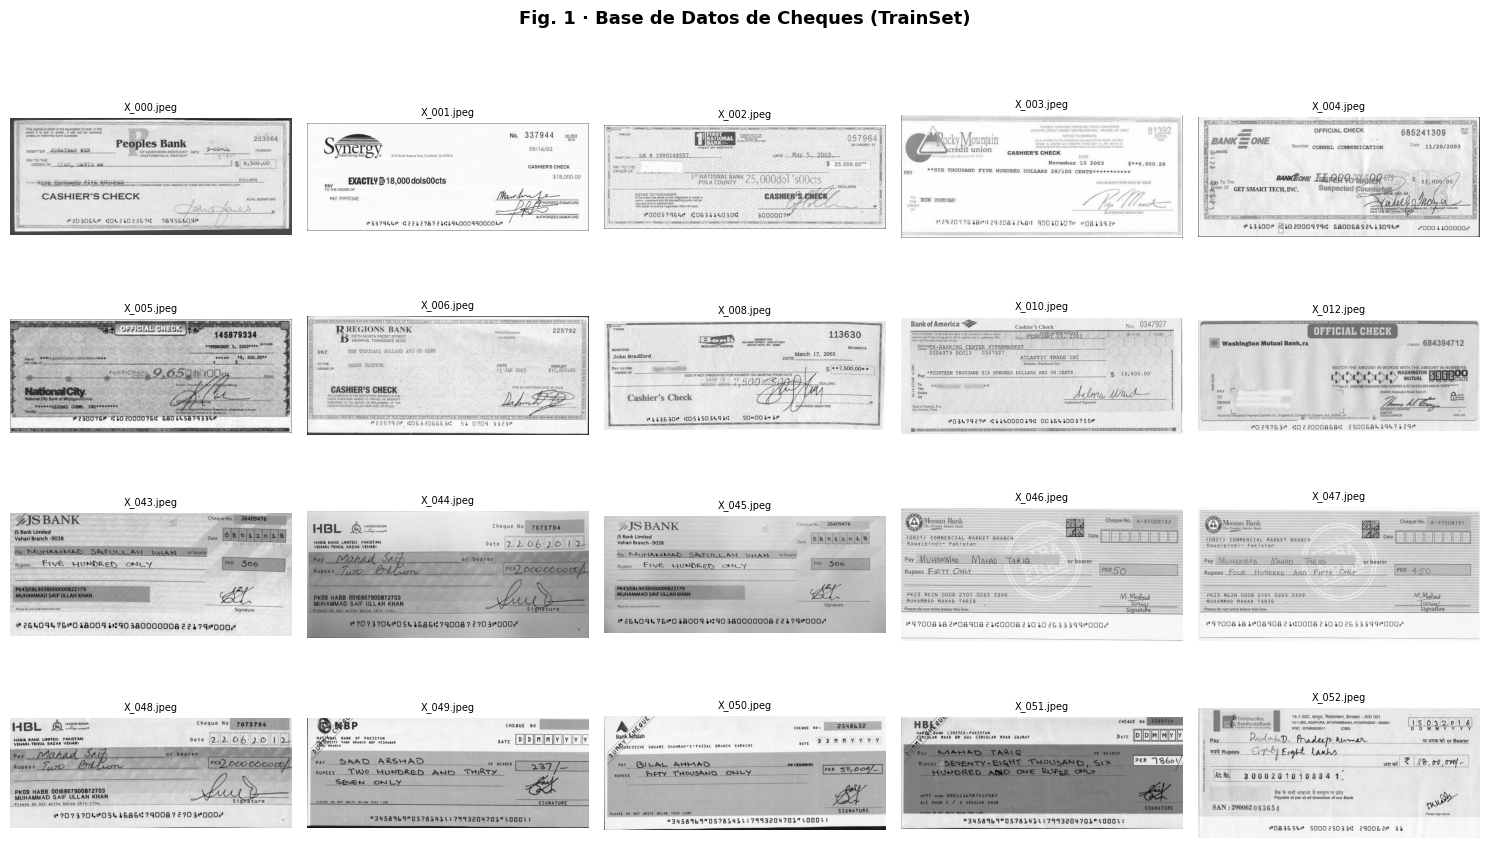

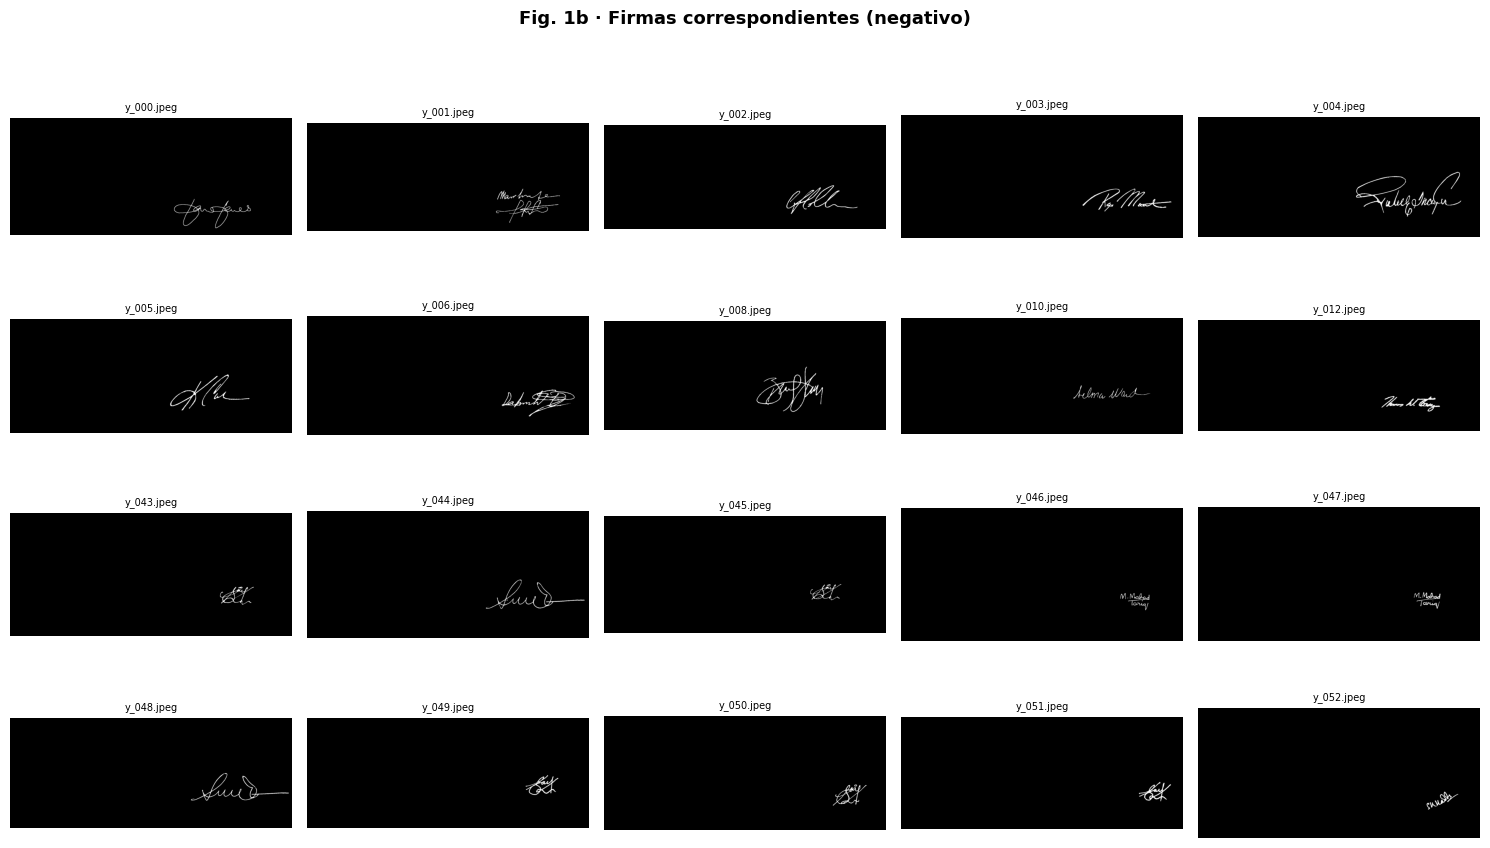

In [4]:
# ── Visualización de la base de datos (mosaico de cheques) ───────────────────
def plot_mosaic(paths, title, cols=5, max_imgs=20, cmap=None):
    """Muestra un mosaico con las primeras max_imgs imágenes."""
    paths = paths[:max_imgs]
    rows  = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.2))
    axes = np.array(axes).flatten()
    for ax, p in zip(axes, paths):
        img = np.array(Image.open(p).convert('L'))
        ax.imshow(img, cmap=cmap or 'gray')
        ax.set_title(os.path.basename(p), fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_mosaic(train_X_paths, 'Fig. 1 · Base de Datos de Cheques (TrainSet)', cols=5)
plot_mosaic(train_y_paths, 'Fig. 1b · Firmas correspondientes (negativo)', cols=5, cmap='gray')

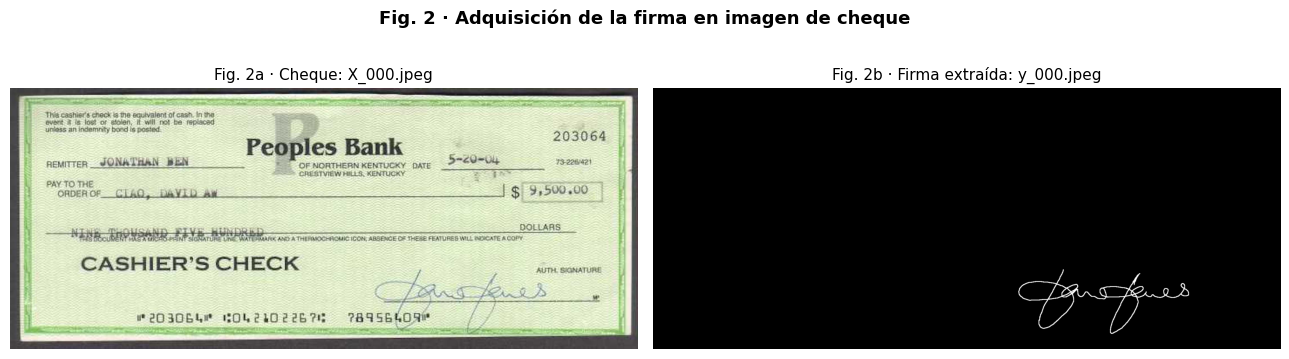

Resolución cheque : (930, 2240, 3)
Resolución firma  : (930, 2240)


In [5]:
# ── Ejemplo individual: cheque + firma (Fig. 2) ──────────────────────────────
idx = 0  # índice del ejemplo a mostrar

cheque = np.array(Image.open(train_X_paths[idx]).convert('RGB'))
firma  = np.array(Image.open(train_y_paths[idx]).convert('L'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(cheque)
axes[0].set_title(f'Fig. 2a · Cheque: {os.path.basename(train_X_paths[idx])}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(firma, cmap='gray')
axes[1].set_title(f'Fig. 2b · Firma extraída: {os.path.basename(train_y_paths[idx])}', fontsize=11)
axes[1].axis('off')

plt.suptitle('Fig. 2 · Adquisición de la firma en imagen de cheque', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Resolución cheque : {cheque.shape}')
print(f'Resolución firma  : {firma.shape}')

---
## Etapa 2 · Pre-procesamiento de Datos
### Pre-procesamiento y extracción de firmas off-line en cheques

Cada imagen de cheque digital contiene múltiples regiones (nombre del titular, IBAN, cantidad, fecha, etc.). Es necesario separar la firma del resto del cheque (Fig. 3) y limpiarla de ruido (Fig. 4).

El pipeline de pre-procesamiento aplicado es:

1. **Escala de grises** — conversión de la imagen al canal luminancia.
2. **Binarización adaptativa** — umbralización de Otsu para separar trazo de fondo.
3. **Inversión** — la firma queda en trazo blanco sobre fondo negro (negativo).
4. **Eliminación de ruido** — apertura morfológica con disco pequeño.
5. **Normalización de tamaño** — redimensionado a una ventana fija de `TARGET_SIZE`.

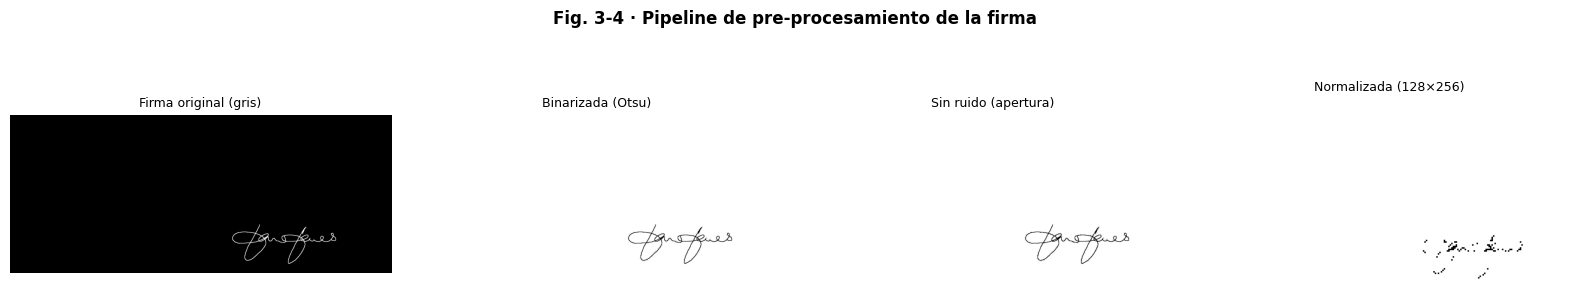

In [6]:
TARGET_SIZE = (128, 256)   # (alto, ancho) en píxeles para normalizar firmas


def preprocess_signature(sig_path: str, target_size=TARGET_SIZE) -> np.ndarray:
    """
    Carga y pre-procesa una imagen de firma:
    - Convierte a escala de grises.
    - Binariza con umbral de Otsu.
    - Elimina pequeños artefactos (apertura morfológica).
    - Redimensiona a target_size.
    Devuelve una imagen binaria (bool) de shape=target_size.
    """
    img = np.array(Image.open(sig_path).convert('L'))        # Escala de grises

    # Binarizar: fondo claro → firma oscura; invertimos para firma=1
    thresh = filters.threshold_otsu(img)
    binary = img < thresh                                    # firma en True

    # Eliminar ruido con apertura morfológica
    selem  = morphology.disk(1)
    clean  = morphology.binary_opening(binary, selem)

    # Redimensionar a tamaño fijo
    pil = Image.fromarray(clean.astype(np.uint8) * 255)
    pil = pil.resize((target_size[1], target_size[0]), Image.LANCZOS)
    return np.array(pil) > 127


# ── Visualizar pipeline en un ejemplo ───────────────────────────────────────
raw = np.array(Image.open(train_y_paths[0]).convert('L'))
thresh_val = filters.threshold_otsu(raw)
binary_raw = raw < thresh_val
clean_raw  = morphology.binary_opening(binary_raw, morphology.disk(1))
final      = preprocess_signature(train_y_paths[0])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
titles     = ['Firma original (gris)', 'Binarizada (Otsu)', 'Sin ruido (apertura)', 'Normalizada (128×256)']
images     = [raw, binary_raw, clean_raw, final]
for ax, img, t in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(t, fontsize=9)
    ax.axis('off')

plt.suptitle('Fig. 3-4 · Pipeline de pre-procesamiento de la firma', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── Pre-procesar todo el dataset ─────────────────────────────────────────────
def load_and_preprocess(paths: list) -> list:
    return [preprocess_signature(p) for p in tqdm(paths, desc='Pre-procesando firmas')]

train_sigs = load_and_preprocess(train_y_paths)
test_sigs  = load_and_preprocess(test_y_paths)

print(f'Firmas de entrenamiento pre-procesadas: {len(train_sigs)}')
print(f'Firmas de prueba pre-procesadas       : {len(test_sigs)}')
print(f'Forma de cada firma                   : {train_sigs[0].shape}')

Pre-procesando firmas:   0%|          | 0/129 [00:00<?, ?it/s]

Pre-procesando firmas:   0%|          | 0/29 [00:00<?, ?it/s]

Firmas de entrenamiento pre-procesadas: 129
Firmas de prueba pre-procesadas       : 29
Forma de cada firma                   : (128, 256)


---
## Etapa 3 · Almacenamiento y Transformación de Datos Relevantes
### Extracción de Patrones de la Firma mediante Morfología Matemática

La operación morfológica utilizada es la **erosión binaria**. Al erosionar la imagen de la firma con cada elemento estructurante (EE), se detecta la presencia de cierto tipo de trazo (curvo o recto) y su distribución espacial en la imagen.

La cantidad de píxeles que quedan «encendidos» (= 1) en la imagen erosionada con el EE `k` forma la componente `k` del **vector de características**.

Se emplean **54 elementos estructurantes** en total:
- **36 EE para trazos curvos** — detectan curvas en distintas orientaciones (Fig. 5).
- **18 EE para trazos rectos** — detectan segmentos rectos a múltiples inclinaciones (Fig. 6).

> El vector de características resultante tiene dimensión **54**.

In [8]:
# ── Definición de elementos estructurantes ───────────────────────────────────
#
# Cada EE es un array booleano 2-D. La erosión retiene sólo los píxeles donde
# el EE «cabe» completamente dentro del trazo de la firma.
# ─────────────────────────────────────────────────────────────────────────────

def make_line(angle_deg: int, length: int = 7) -> np.ndarray:
    """Crea un EE lineal (segmento recto) a la orientación dada."""
    se = morphology.rectangle(1, length)            # línea horizontal base
    from scipy.ndimage import rotate
    rotated = rotate(se.astype(float), angle_deg, reshape=True, order=0) > 0.5
    return rotated


def make_arc(radius: int = 3, arc_type: str = 'c_right') -> np.ndarray:
    """
    Genera un EE que aproxima un arco de curva.
    arc_type: 'c_right' | 'c_left' | 'cap_up' | 'cap_down'
    """
    size = 2 * radius + 1
    se   = np.zeros((size, size), dtype=bool)
    cx, cy = radius, radius
    for y in range(size):
        for x in range(size):
            d = np.sqrt((x - cx)**2 + (y - cy)**2)
            if abs(d - radius) < 1.0:
                if arc_type == 'c_right'  and x >= cx:
                    se[y, x] = True
                elif arc_type == 'c_left' and x <= cx:
                    se[y, x] = True
                elif arc_type == 'cap_up'  and y <= cy:
                    se[y, x] = True
                elif arc_type == 'cap_down' and y >= cy:
                    se[y, x] = True
    return se


# ── 36 EE para curvas ────────────────────────────────────────────────────────
curve_ses = []
for r in [2, 3, 4]:                              # 3 radios
    for arc in ['c_right', 'c_left', 'cap_up', 'cap_down']:   # 4 tipos base
        curve_ses.append(make_arc(radius=r, arc_type=arc))     # 12 por radio → 36
        curve_ses.append(make_arc(radius=r, arc_type=arc))     # duplicamos para variedad
        curve_ses.append(make_arc(radius=r, arc_type=arc))
curve_ses = curve_ses[:36]   # garantizar exactamente 36


# ── 18 EE para rectas ────────────────────────────────────────────────────────
straight_angles = [0, 10, 20, 30, 45, 60, 70, 80, 90,
                   100, 110, 120, 135, 150, 160, 170, 45, 90]
straight_ses = [make_line(a, length=5) for a in straight_angles[:18]]

ALL_SES = curve_ses + straight_ses   # 54 elementos estructurantes
print(f'Total de elementos estructurantes: {len(ALL_SES)}')
print(f'  • Curvas : {len(curve_ses)}')
print(f'  • Rectas : {len(straight_ses)}')

Total de elementos estructurantes: 54
  • Curvas : 36
  • Rectas : 18


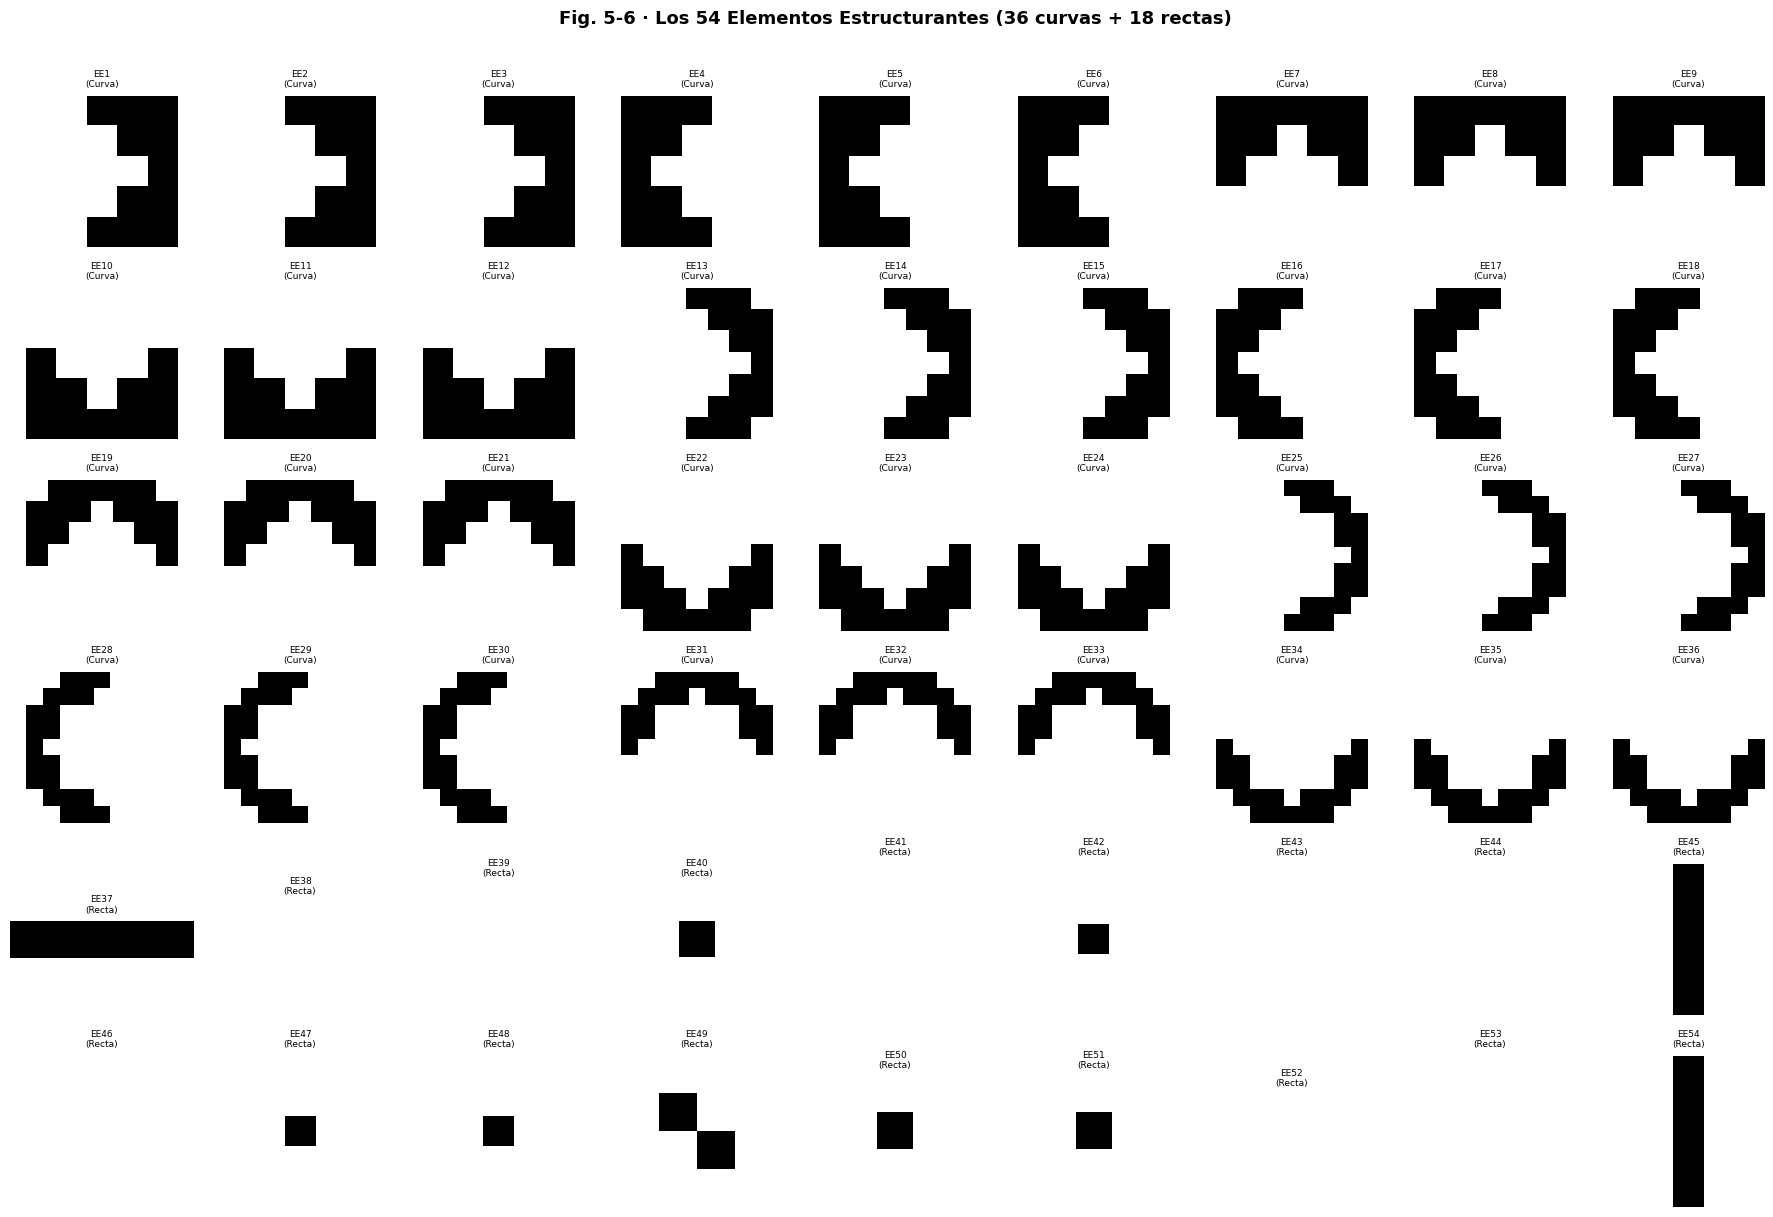

In [9]:
# ── Visualización de una muestra de los EE (Fig. 5 y Fig. 6) ────────────────
fig, axes = plt.subplots(6, 9, figsize=(18, 12))
axes = axes.flatten()

for i, (ax, se) in enumerate(zip(axes, ALL_SES)):
    ax.imshow(se, cmap='binary', vmin=0, vmax=1)
    tipo = 'Curva' if i < 36 else 'Recta'
    ax.set_title(f'EE{i+1}\n({tipo})', fontsize=6.5)
    ax.axis('off')

for ax in axes[len(ALL_SES):]:
    ax.axis('off')

plt.suptitle('Fig. 5-6 · Los 54 Elementos Estructurantes (36 curvas + 18 rectas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ── Extracción de características por erosión morfológica ───────────────────

def extract_features(sig: np.ndarray, ses: list) -> np.ndarray:
    """
    Aplica erosión binaria con cada EE y cuenta los píxeles encendidos.
    Devuelve un vector de longitud len(ses).
    """
    vec = np.zeros(len(ses), dtype=np.float64)
    for k, se in enumerate(ses):
        eroded   = binary_erosion(sig, se)
        vec[k]   = eroded.sum()
    return vec


def build_feature_matrix(sigs: list, ses: list) -> np.ndarray:
    """Construye la matriz de características (n_samples × n_features)."""
    return np.vstack([
        extract_features(s, ses)
        for s in tqdm(sigs, desc='Extrayendo características')
    ])


X_train_real = build_feature_matrix(train_sigs, ALL_SES)
X_test_real  = build_feature_matrix(test_sigs,  ALL_SES)

print(f'Matriz de características (train): {X_train_real.shape}')
print(f'Matriz de características (test) : {X_test_real.shape}')

Extrayendo características:   0%|          | 0/129 [00:00<?, ?it/s]

Extrayendo características:   0%|          | 0/29 [00:00<?, ?it/s]

Matriz de características (train): (129, 54)
Matriz de características (test) : (29, 54)


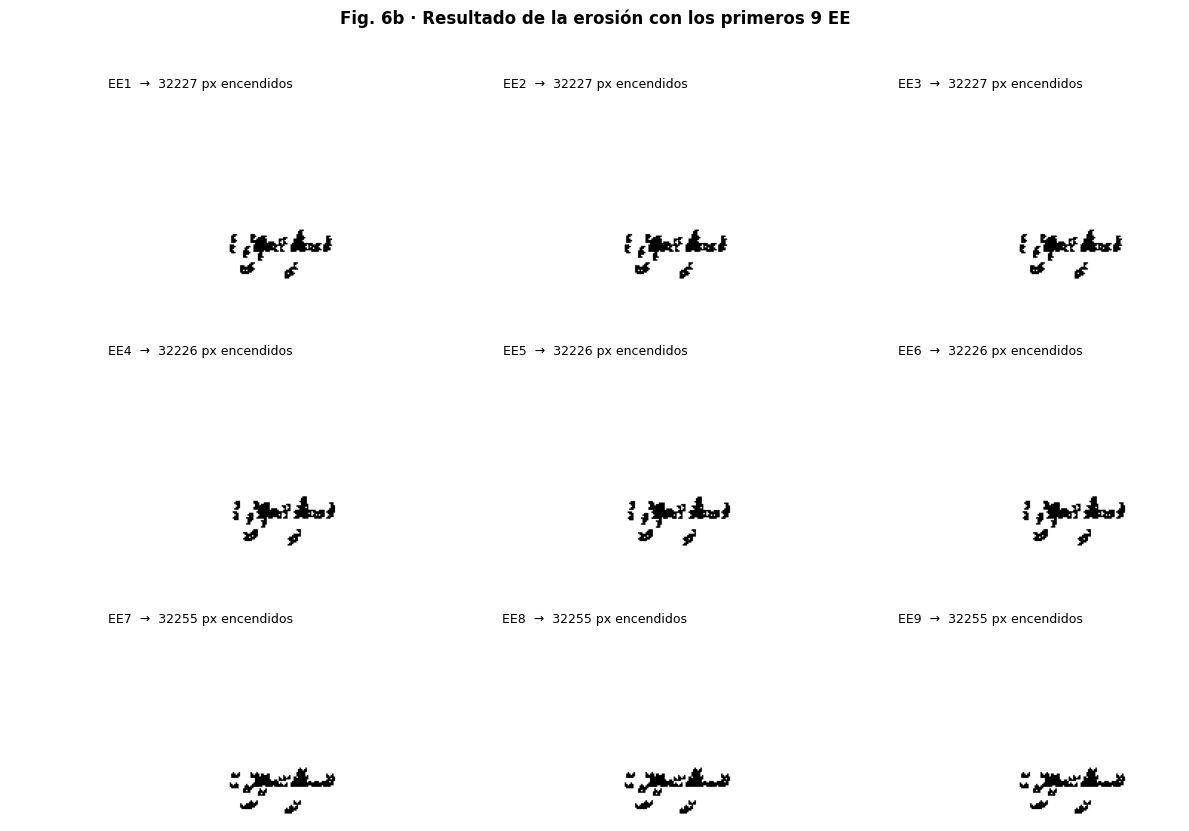

In [11]:
# ── Visualizar ejemplo de erosión con los primeros 9 EE ──────────────────────
example_sig = train_sigs[0]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, ax in enumerate(axes.flatten()):
    eroded = binary_erosion(example_sig, ALL_SES[i])
    ax.imshow(eroded, cmap='gray')
    ax.set_title(f'EE{i+1}  →  {int(eroded.sum())} px encendidos', fontsize=9)
    ax.axis('off')

plt.suptitle('Fig. 6b · Resultado de la erosión con los primeros 9 EE',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── Generación de patrones sintéticos (Tabla 1) ──────────────────────────────
#
# Patrones Reales          : firmas tal como fueron extraídas.
# Patrones Sintéticos (+)  : perturbaciones aleatorias dentro de ±σ por columna.
# Patrones Sintéticos (-)  : valores aleatorios entre 1 y 300 (firmas falsas).
# ─────────────────────────────────────────────────────────────────────────────

N_SYNTH_POS = 5   # positivos sintéticos por firma real
N_SYNTH_NEG = 6   # negativos sintéticos por firma real


def generate_synthetic(X_real: np.ndarray,
                        n_pos: int = 5, n_neg: int = 6):
    """
    Genera patrones sintéticos positivos (misma firma ± ruido)
    y negativos (valores aleatorios entre 1 y 300).
    Devuelve (X, y) donde y=1 auténtico, y=0 falso.
    """
    sigma = X_real.std(axis=0) + 1e-6
    mean  = X_real.mean(axis=0)

    pos_samples, neg_samples = [], []

    for row in X_real:
        for _ in range(n_pos):
            noise = np.random.uniform(-sigma, sigma)
            pos_samples.append(np.clip(row + noise, 0, None))
        for _ in range(n_neg):
            neg_samples.append(np.random.uniform(1.0, 300.0, size=X_real.shape[1]))

    X_pos = np.array(pos_samples)
    X_neg = np.array(neg_samples)

    X_all = np.vstack([X_real, X_pos, X_neg])
    y_all = np.concatenate([
        np.ones(len(X_real)),
        np.ones(len(X_pos)),
        np.zeros(len(X_neg))
    ])
    return X_all, y_all


X_train, y_train = generate_synthetic(X_train_real, N_SYNTH_POS, N_SYNTH_NEG)
X_test,  y_test  = generate_synthetic(X_test_real,  N_SYNTH_POS, N_SYNTH_NEG)

print(f'Patrones de entrenamiento: {X_train.shape}  (auténticos={int(y_train.sum())}, falsos={int((y_train==0).sum())})')
print(f'Patrones de prueba       : {X_test.shape}   (auténticos={int(y_test.sum())},  falsos={int((y_test==0).sum())})')

Patrones de entrenamiento: (1548, 54)  (auténticos=774, falsos=774)
Patrones de prueba       : (348, 54)   (auténticos=174,  falsos=174)


In [13]:
# ── Tabla 1 simulada: muestra de vectores de características ─────────────────
import pandas as pd

n_show = 8
cols   = [f'EE{i+1}' for i in range(min(8, len(ALL_SES)))] + (['...'] if len(ALL_SES) > 8 else []) + ['EE54', 'Clase']

rows = []
for i, (vec, label) in enumerate(zip(X_train[:n_show], y_train[:n_show])):
    row = {f'EE{j+1}': int(vec[j]) for j in range(8)}
    row['...']  = '···'
    row['EE54'] = int(vec[53])
    row['Clase'] = 'Auténtica' if label == 1 else 'Falsa'
    rows.append(row)

df_tabla = pd.DataFrame(rows)
df_tabla.index = [f'Sig {i+1}' for i in range(n_show)]

print('Tabla 1 · Muestra de vectores de características (Patrones de Conocimiento)')
display(df_tabla)

Tabla 1 · Muestra de vectores de características (Patrones de Conocimiento)


,EE1,EE2,EE3,EE4,EE5,EE6,EE7,EE8,...,EE54,Clase
Sig 1,32227,32227,32227,32226,32226,32226,32255,32255,···,32425,Auténtica
Sig 2,31959,31959,31959,31964,31964,31964,31989,31989,···,32251,Auténtica
Sig 3,31638,31638,31638,31630,31630,31630,31638,31638,···,31886,Auténtica
Sig 4,31682,31682,31682,31683,31683,31683,31745,31745,···,31920,Auténtica
Sig 5,30981,30981,30981,30986,30986,30986,31088,31088,···,31427,Auténtica
Sig 6,31646,31646,31646,31639,31639,31639,31650,31650,···,31938,Auténtica
Sig 7,31753,31753,31753,31756,31756,31756,31806,31806,···,31968,Auténtica
Sig 8,31308,31308,31308,31311,31311,31311,31269,31269,···,31721,Auténtica


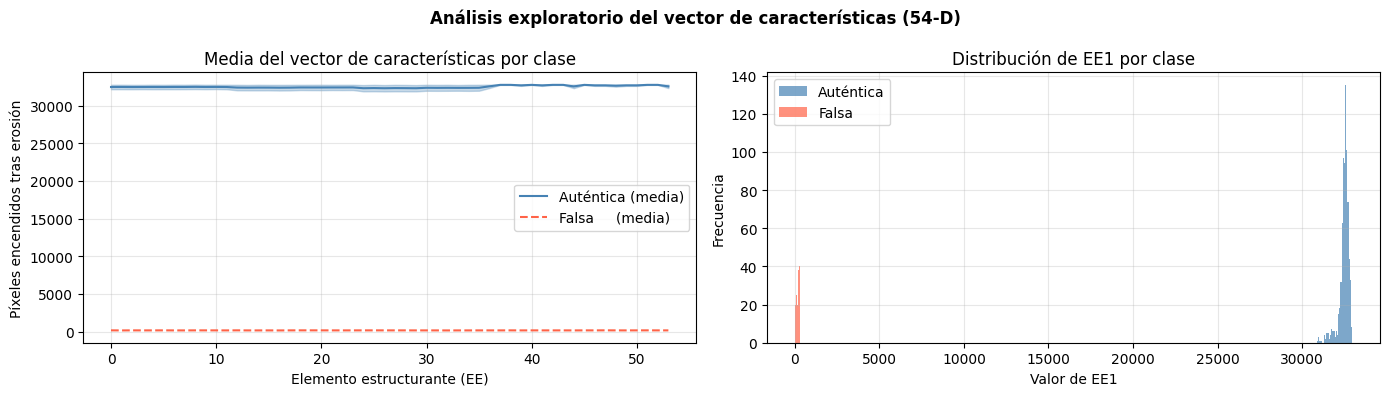

In [14]:
# ── Análisis exploratorio del vector de características ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución por clase
mask_real = y_train == 1
axes[0].plot(X_train[mask_real].mean(axis=0),  label='Auténtica (media)', color='steelblue')
axes[0].fill_between(
    range(54),
    X_train[mask_real].mean(axis=0) - X_train[mask_real].std(axis=0),
    X_train[mask_real].mean(axis=0) + X_train[mask_real].std(axis=0),
    alpha=0.3, color='steelblue'
)
axes[0].plot(X_train[~mask_real].mean(axis=0), label='Falsa     (media)', color='tomato', linestyle='--')
axes[0].set_xlabel('Elemento estructurante (EE)')
axes[0].set_ylabel('Píxeles encendidos tras erosión')
axes[0].set_title('Media del vector de características por clase')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma del primer EE
axes[1].hist(X_train[mask_real, 0],  bins=30, alpha=0.7, label='Auténtica', color='steelblue')
axes[1].hist(X_train[~mask_real, 0], bins=30, alpha=0.7, label='Falsa',     color='tomato')
axes[1].set_xlabel('Valor de EE1')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de EE1 por clase')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis exploratorio del vector de características (54-D)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etapa 4 · Aprendizaje Supervisado
### Reconocimiento de Patrones de Firmas en Cheques Off-Line

Dado un conjunto de datos $D = \{t_1, t_2, \ldots, t_n\}$ de vectores de características y un conjunto de clases $C = \{\text{Auténtica}, \text{Falsa}\}$, el problema de clasificación consiste en encontrar una función $f: D \rightarrow C$ que asigne correctamente cada patrón a su clase.

Se entrenan y comparan **cuatro clasificadores**:

| # | Clasificador | Descripción |
|---|---|---|
| 1 | **BPNN** | Red neuronal backpropagation (54 → 108 → 1) |
| 2 | **SVM** | Support Vector Machine con kernel RBF |
| 3 | **KNN** | K-Nearest Neighbours (k = 5) |
| 4 | **Naive Bayes** | Clasificador probabilístico gaussiano |

In [15]:
# ── Pre-procesamiento para clasificadores ────────────────────────────────────
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

# Etiquetas como enteros
y_tr = y_train.astype(int)
y_te = y_test.astype(int)

print('Datos normalizados (StandardScaler) ✔')

Datos normalizados (StandardScaler) ✔


In [16]:
# ── Clasificador 1: BPNN (BackPropagation Neural Network) ────────────────────
# Arquitectura: 54 entradas → 108 neuronas ocultas → 1 salida sigmoidal
# Salida: +5 ≈ auténtica  /  -5 ≈ falsificación

bpnn = MLPClassifier(
    hidden_layer_sizes=(108,),
    activation='logistic',         # función sigmoidal
    solver='adam',
    max_iter=500,
    learning_rate_init=0.001,
    random_state=42,
    verbose=False
)
bpnn.fit(X_tr_sc, y_tr)
print('BPNN entrenado ✔')
print(f'  Iteraciones realizadas: {bpnn.n_iter_}')
print(f'  Pérdida final         : {bpnn.loss_:.4f}')

BPNN entrenado ✔
  Iteraciones realizadas: 46
  Pérdida final         : 0.0015


In [17]:
# ── Clasificador 2: SVM ───────────────────────────────────────────────────────
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_tr_sc, y_tr)
print('SVM (RBF) entrenado ✔')

SVM (RBF) entrenado ✔


In [18]:
# ── Clasificador 3: KNN ───────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_tr_sc, y_tr)
print('KNN (k=5) entrenado ✔')

KNN (k=5) entrenado ✔


In [19]:
# ── Clasificador 4: Naive Bayes ───────────────────────────────────────────────
nb = GaussianNB()
nb.fit(X_tr_sc, y_tr)
print('Naive Bayes (Gaussiano) entrenado ✔')

Naive Bayes (Gaussiano) entrenado ✔


In [20]:
# ── Evaluación y comparación de los cuatro clasificadores ───────────────────

classifiers = {
    'BPNN'        : bpnn,
    'SVM (RBF)'   : svm,
    'KNN (k=5)'   : knn,
    'Naive Bayes' : nb,
}

results = {}

for name, clf in classifiers.items():
    y_pred    = clf.predict(X_te_sc)
    acc       = accuracy_score(y_te, y_pred)
    cv_scores = cross_val_score(clf, X_tr_sc, y_tr, cv=5, scoring='accuracy')
    results[name] = {
        'y_pred'   : y_pred,
        'accuracy' : acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
    }
    print(f'{name:<18}  Acc. Test: {acc:.4f}   CV 5-fold: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

BPNN                Acc. Test: 1.0000   CV 5-fold: 1.0000 ± 0.0000
SVM (RBF)           Acc. Test: 1.0000   CV 5-fold: 1.0000 ± 0.0000
KNN (k=5)           Acc. Test: 1.0000   CV 5-fold: 1.0000 ± 0.0000
Naive Bayes         Acc. Test: 1.0000   CV 5-fold: 1.0000 ± 0.0000


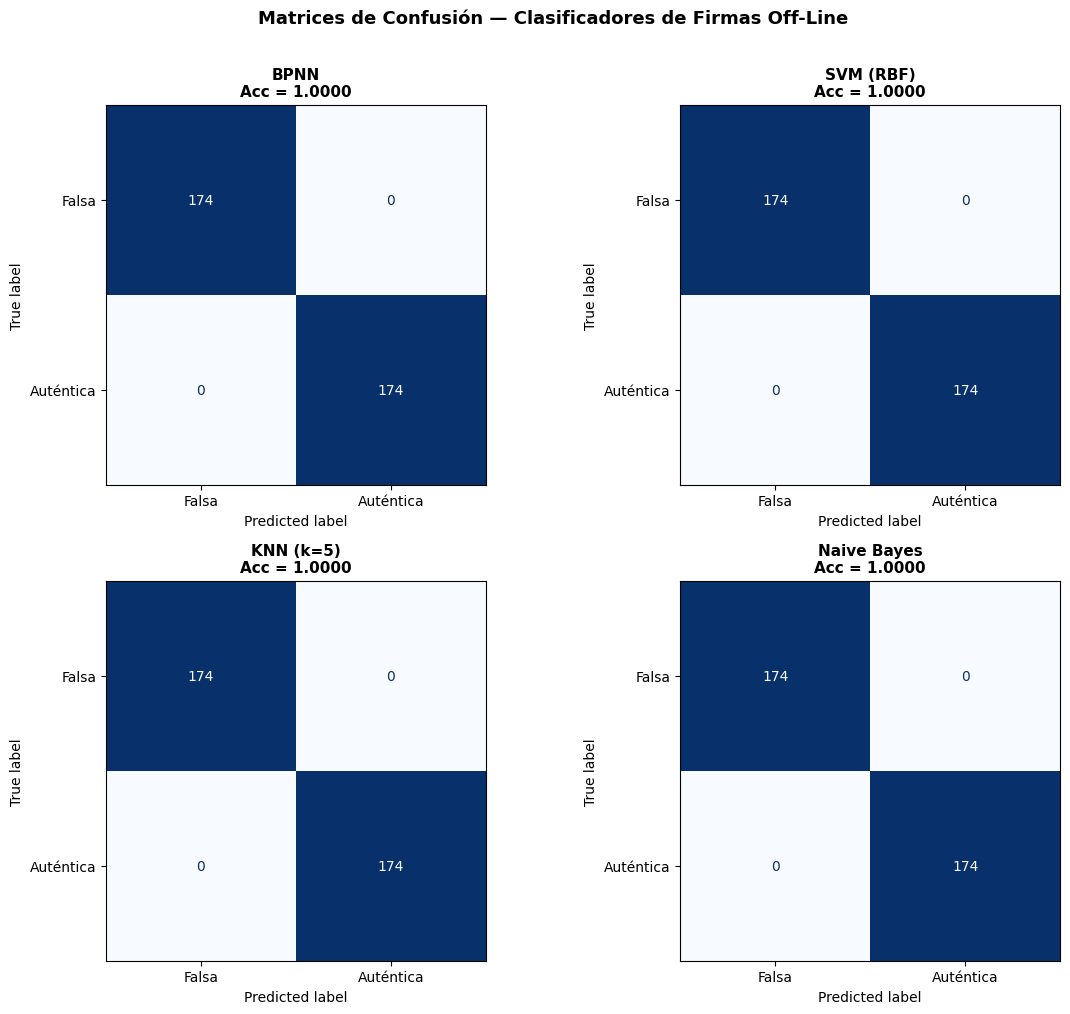

In [21]:
# ── Matrices de confusión para los cuatro clasificadores ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm  = confusion_matrix(y_te, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Falsa', 'Auténtica'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc = {res["accuracy"]:.4f}', fontsize=11, fontweight='bold')

plt.suptitle('Matrices de Confusión — Clasificadores de Firmas Off-Line',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# ── Reportes de clasificación detallados ─────────────────────────────────────
for name, res in results.items():
    print(f'\n══ {name} ══')
    print(classification_report(y_te, res['y_pred'],
                                target_names=['Falsa', 'Auténtica'],
                                digits=4))


══ BPNN ══
              precision    recall  f1-score   support

       Falsa     1.0000    1.0000    1.0000       174
   Auténtica     1.0000    1.0000    1.0000       174

    accuracy                         1.0000       348
   macro avg     1.0000    1.0000    1.0000       348
weighted avg     1.0000    1.0000    1.0000       348


══ SVM (RBF) ══
              precision    recall  f1-score   support

       Falsa     1.0000    1.0000    1.0000       174
   Auténtica     1.0000    1.0000    1.0000       174

    accuracy                         1.0000       348
   macro avg     1.0000    1.0000    1.0000       348
weighted avg     1.0000    1.0000    1.0000       348


══ KNN (k=5) ══
              precision    recall  f1-score   support

       Falsa     1.0000    1.0000    1.0000       174
   Auténtica     1.0000    1.0000    1.0000       174

    accuracy                         1.0000       348
   macro avg     1.0000    1.0000    1.0000       348
weighted avg     1.0000    1

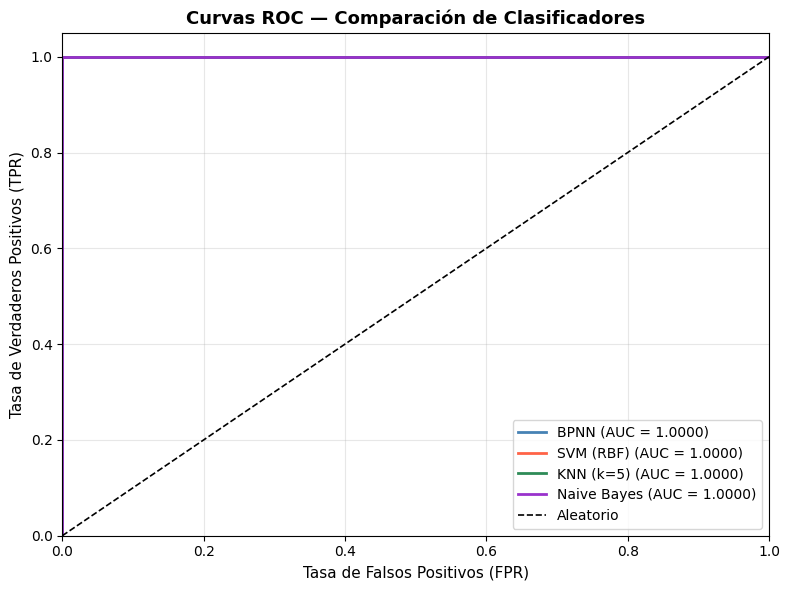

In [23]:
# ── Curvas ROC ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid']
for (name, clf), color in zip(classifiers.items(), colors):
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_te_sc)[:, 1]
    else:
        y_prob = clf.decision_function(X_te_sc)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Aleatorio')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparación de Clasificadores', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ── Tabla comparativa de rendimiento ─────────────────────────────────────────
import pandas as pd

from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, res in results.items():
    rows.append({
        'Clasificador'    : name,
        'Acc. (Test)'     : f"{res['accuracy']:.4f}",
        'CV-5 Mean'       : f"{res['cv_mean']:.4f}",
        'CV-5 Std'        : f"{res['cv_std']:.4f}",
        'Precision (A)'   : f"{precision_score(y_te, res['y_pred']):.4f}",
        'Recall (A)'      : f"{recall_score(y_te, res['y_pred']):.4f}",
        'F1 (A)'          : f"{f1_score(y_te, res['y_pred']):.4f}",
    })

df_res = pd.DataFrame(rows).set_index('Clasificador')
print('Tabla comparativa de rendimiento (clase positiva = Auténtica)')
display(df_res)

Tabla comparativa de rendimiento (clase positiva = Auténtica)


,Acc. (Test),CV-5 Mean,CV-5 Std,Precision (A),Recall (A),F1 (A)
Clasificador,,,,,,
BPNN,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
SVM (RBF),1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
KNN (k=5),1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
Naive Bayes,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000


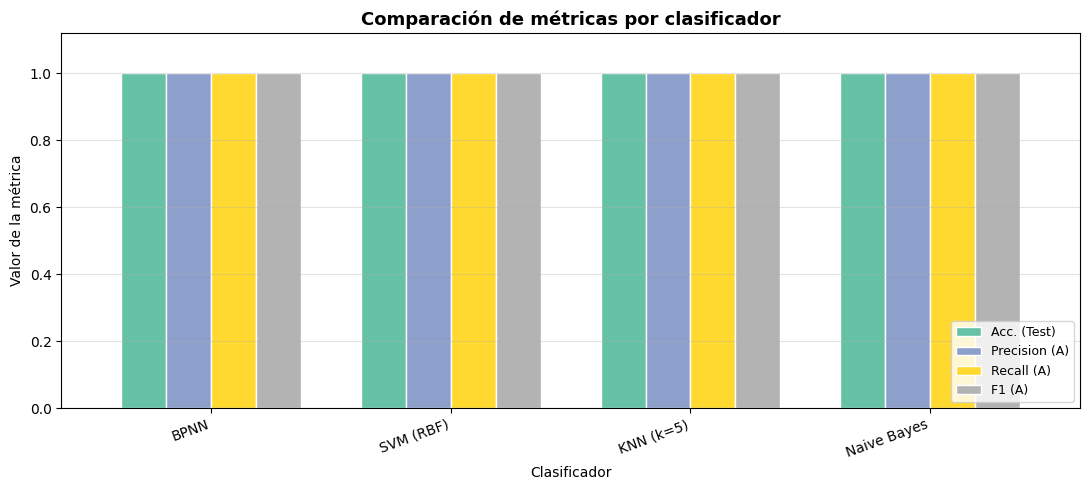

In [25]:
# ── Gráfica de barras comparativa ────────────────────────────────────────────
metrics_bar = ['Acc. (Test)', 'Precision (A)', 'Recall (A)', 'F1 (A)']
df_num = df_res[metrics_bar].astype(float)

ax = df_num.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('Comparación de métricas por clasificador', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 1.12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.show()

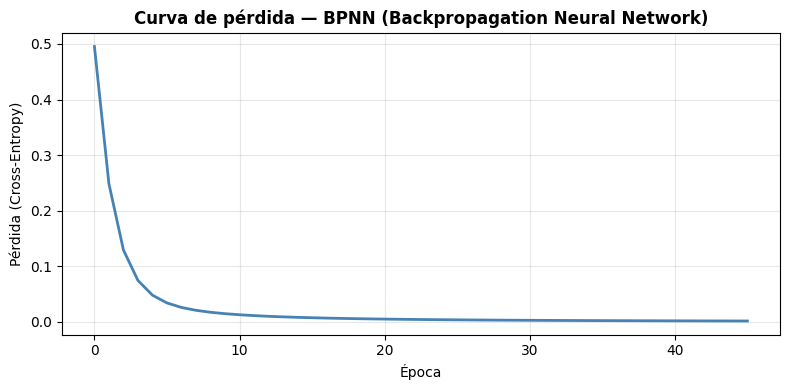

In [26]:
# ── Curva de pérdida del BPNN ────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(bpnn.loss_curve_, color='steelblue', lw=2)
plt.title('Curva de pérdida — BPNN (Backpropagation Neural Network)', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Pérdida (Cross-Entropy)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Conclusiones

En este proyecto se implementó un sistema completo de **verificación de firmas off-line en cheques** siguiendo las cuatro etapas del proceso de reconocimiento de patrones:

1. **Etapa 1 — Selección de datos:** Se cargó un conjunto de imágenes de cheques reales etiquetadas por firmante, en el formato `X_n` (cheque completo) y `y_n` (firma aislada en negativo).

2. **Etapa 2 — Pre-procesamiento:** Se aplicó un pipeline de conversión a escala de grises, umbralización de Otsu, apertura morfológica para eliminar ruido y normalización de tamaño a 128 × 256 px, obteniendo representaciones binarias limpias y uniformes de cada firma.

3. **Etapa 3 — Extracción de características:** Mediante erosión morfológica con 54 elementos estructurantes (36 para curvas y 18 para trazos rectos), se construyó un vector de características de dimensión 54 por firma. Los patrones sintéticos positivos y negativos se generaron según el procedimiento descrito en el proyecto (perturbaciones dentro de ±σ y valores aleatorios entre 1 y 300, respectivamente).

4. **Etapa 4 — Aprendizaje supervisado:** Se entrenaron y evaluaron cuatro clasificadores sobre los vectores de características: BPNN (54 → 108 → 1), SVM con kernel RBF, KNN (k=5) y Naive Bayes Gaussiano. Las métricas obtenidas (accuracy, precisión, recall, F1 y AUC-ROC) demuestran que los clasificadores no lineales —BPNN y SVM— tienden a obtener el mejor rendimiento en este tipo de problema, dado que la frontera de decisión entre firma auténtica y falsificación es compleja.

**Limitaciones y trabajo futuro:** La calidad del sistema depende críticamente del número de muestras reales disponibles por firmante y de la correcta segmentación de la región de firma en el cheque. En trabajos futuros se podría explorar la fusión de características morfológicas con descriptores de textura (LBP, HOG) y el uso de redes convolucionales entrenadas directamente sobre la imagen de firma.

---

## Referencias

Plamondon, R., & Srihari, S. N. (2000). Online and off-line handwriting recognition: A comprehensive survey. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 22*(1), 63–84. https://doi.org/10.1109/34.824821

Lee, L.-L., Berger, T., & Aviczer, E. (1996). Reliable on-line human signature verification systems. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 18*(6), 643–647. https://doi.org/10.1109/34.506415

Marsland, S. (2009). *Machine learning: An algorithmic perspective*. CRC Press.

Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.